현재 작업 폴더: c:\Users\human-18\Desktop\Wine_ML_Project
읽는 파일명: winequality-red.csv
컬럼명 확인: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


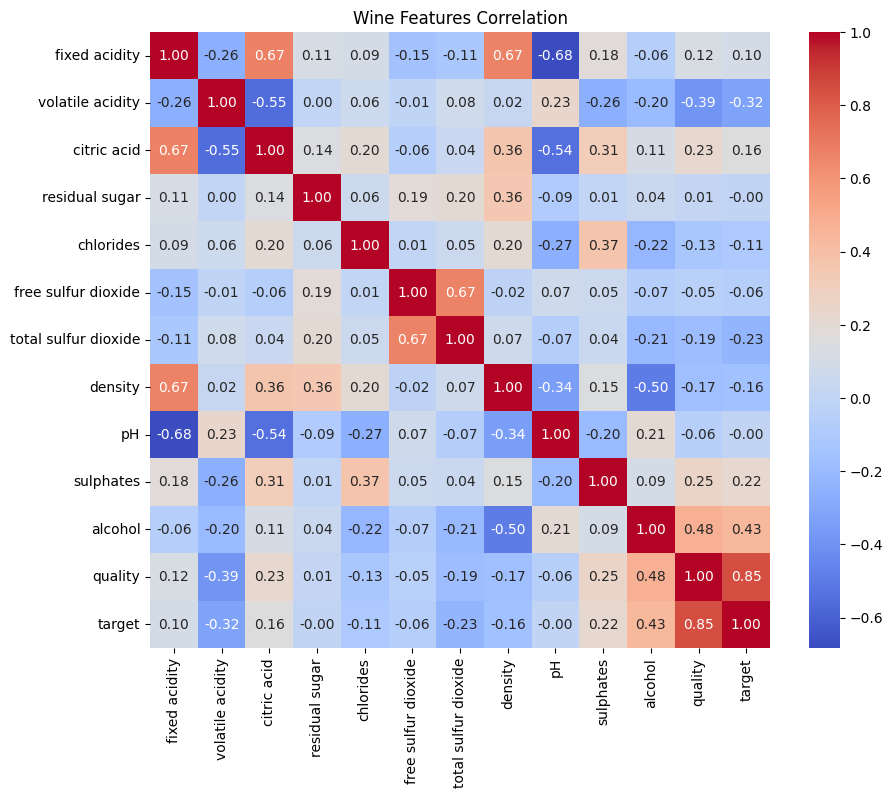

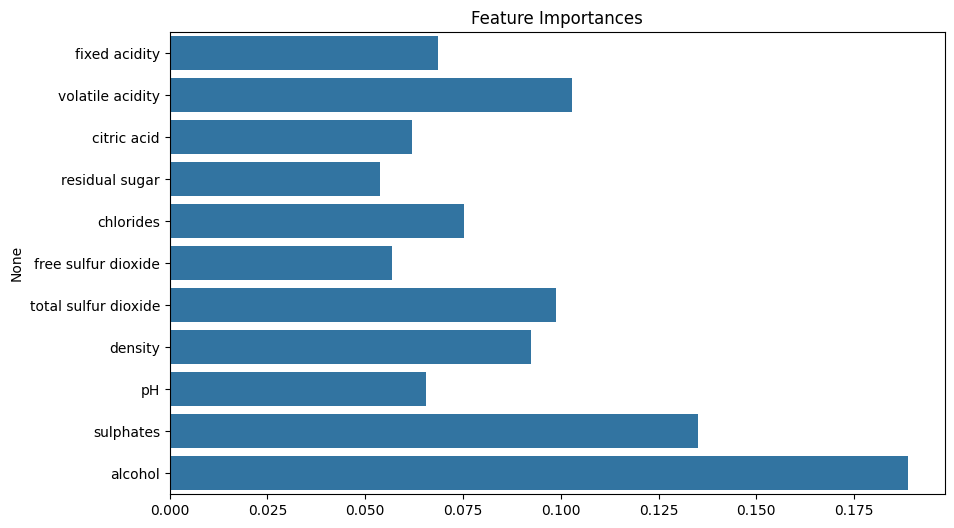

모델 저장 완료: red_model.pkl
현재 작업 폴더: c:\Users\human-18\Desktop\Wine_ML_Project
읽는 파일명: winequality-white.csv
컬럼명 확인: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


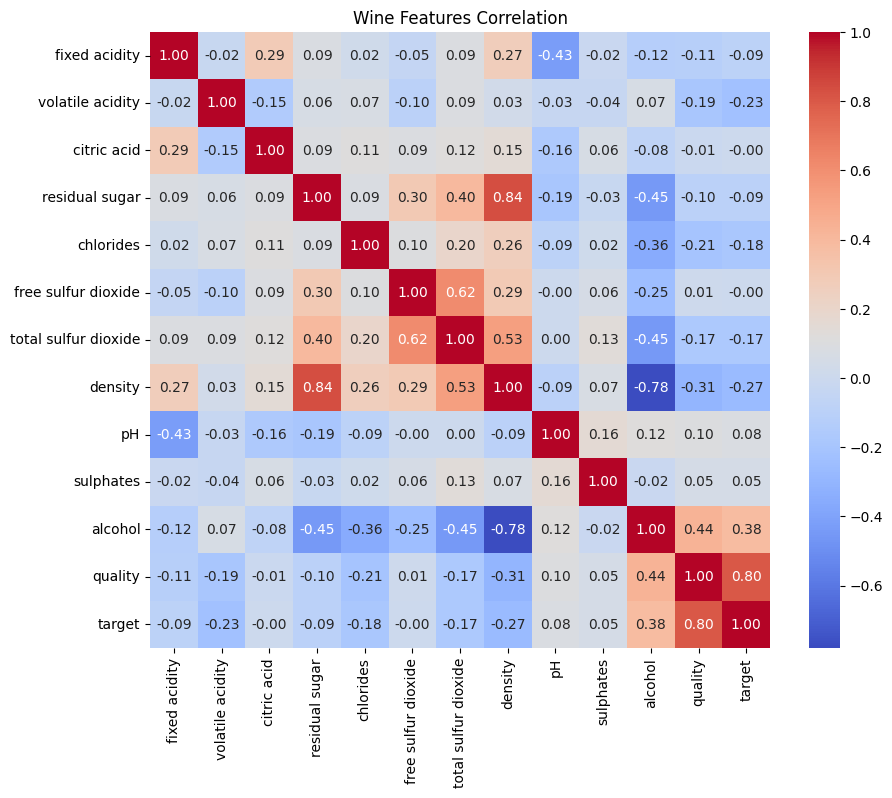

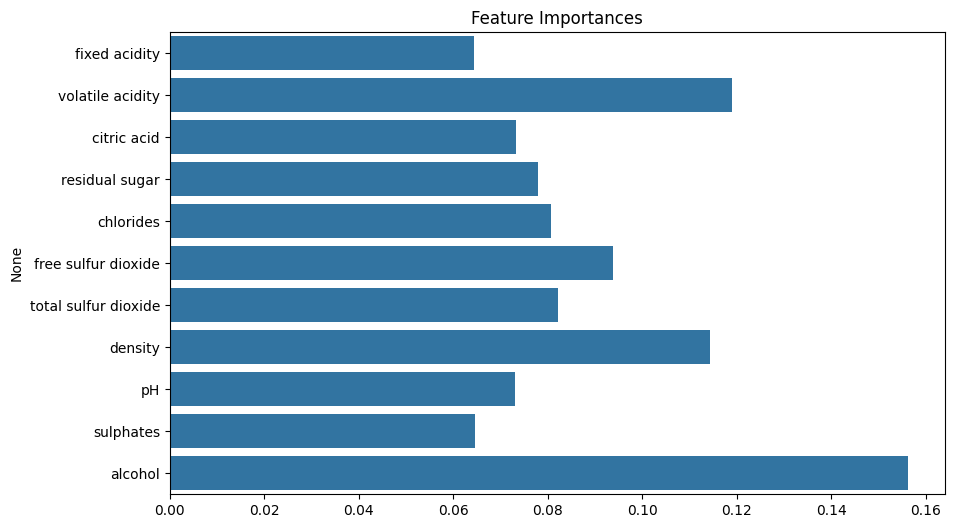

모델 저장 완료: white_model.pkl


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# 🔥 모델 생성 함수
def train_and_save_model(file_name, model_name):
    import os
    print("현재 작업 폴더:", os.getcwd())
    print("읽는 파일명:", file_name)

    if 'white' in file_name:
        df = pd.read_csv(file_name, sep=';')
    else:
        df = pd.read_csv(file_name)

    df.columns = df.columns.str.strip()
    print("컬럼명 확인:", df.columns.tolist())

    df['target'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

    X = df.drop(['quality', 'target'], axis=1)
    y = df['target']

    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)
    
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 1. 상관관계 히트맵 (어떤 성분이 중요한지 보여줌)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Wine Features Correlation')
    plt.show()

    # 2. 모델의 중요도 확인 (AI가 무엇을 보고 판단했나?)
    importances = model.feature_importances_
    indices = X.columns
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances, y=indices)
    plt.title('Feature Importances')
    plt.show()

    import joblib
    joblib.dump(model, model_name)

    print(f"모델 저장 완료: {model_name}")


# 🔥 레드 와인 모델
train_and_save_model('winequality-red.csv', 'red_model.pkl')

# 🔥 화이트 와인 모델
train_and_save_model('winequality-white.csv', 'white_model.pkl')